**Tutorial 2**

This tutorial is based on using  ML package Weka for machine learning. Weka is a famous machine learning software and a set of libraries that one can use within a programming language. Weka was created at the University of Waikato, New Zealnd (https://www.cs.waikato.ac.nz/ml/weka/). It is accompanied with a text book of data mining taught in schools around the world (https://www.cs.waikato.ac.nz/ml/weka/book.html). The advantage of using Weka's Python package is that the implementation of algorithms is complete, comprehsive and easy to use. Let's see below.


First install Weka's Python package.

In [ ]:
! pip install python-weka-wrapper3

Weka was built on Java, and below we shall be setting Java and launching it in Python environment. Don't worry about understanding this code.

We shall now upload a dataset file. Weka works with arff format easily, it can load CSV too. We shall upload .arff file because I have defined the correct data types of variables (cagtegorical or numerical) in it already.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving german_credit.csv to german_credit.csv


In [ ]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['german_credit.csv']))

# Display first few rows
df.head()

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


**Part 1: Data Preperation and Exploration**

***Contributor: ALL GROUP MEMBERS***

Let's load our dataset into memory. It will be loaded using the following code. Dataset file that I have uplaoded is german_credit.arff. Note this loaded data in moemeory is not a Pandas' data frame.

In [ ]:
# Let's look at the attributes, their data types, and unique values.
for i, col in enumerate(df.columns):
    print(f"\nIndex {i}: Column Name - '{col}'")
    print(f"Data Type: {df[col].dtype}")

    unique_values = df[col].unique()
    num_unique = len(unique_values)

    # If too many unique values, display only first 10
    if num_unique > 10:
        print(f"Unique Values ({num_unique} total): {unique_values[:10]} ...")
    else:
        print(f"Unique Values ({num_unique} total): {unique_values}")



Index 0: Column Name - 'Creditability'
Data Type: int64
Unique Values (2 total): [1 0]

Index 1: Column Name - 'Account Balance'
Data Type: int64
Unique Values (4 total): [1 2 4 3]

Index 2: Column Name - 'Duration of Credit (month)'
Data Type: int64
Unique Values (33 total): [18  9 12 10  8  6 24 11 30 48] ...

Index 3: Column Name - 'Payment Status of Previous Credit'
Data Type: int64
Unique Values (5 total): [4 2 3 0 1]

Index 4: Column Name - 'Purpose'
Data Type: int64
Unique Values (10 total): [ 2  0  9  3  1 10  5  4  6  8]

Index 5: Column Name - 'Credit Amount'
Data Type: int64
Unique Values (923 total): [1049 2799  841 2122 2171 2241 3398 1361 1098 3758] ...

Index 6: Column Name - 'Value Savings/Stocks'
Data Type: int64
Unique Values (5 total): [1 2 3 5 4]

Index 7: Column Name - 'Length of current employment'
Data Type: int64
Unique Values (5 total): [2 3 4 1 5]

Index 8: Column Name - 'Instalment per cent'
Data Type: int64
Unique Values (4 total): [4 2 3 1]

Index 9: Colum

In [ ]:
frequency_table = df['Creditability'].value_counts().reset_index()
frequency_table.columns = ['Creditability', 'Frequency']
frequency_table['Percentage'] = (frequency_table['Frequency'] / frequency_table['Frequency'].sum()) * 100

print(frequency_table)

Check for missing values

In [ ]:
# Checking missing values for each column
missing_values = df.isnull().sum()

print("Missing Values per Column:")
for col, count in missing_values.items():
    print(f"{col}: {count} missing values")


Check summary statistics for each attribute for any anomaly

In [ ]:
# Iterate through each column to print summary statistics
for col in df.columns:
    print(f"\n{'-'*50}\nColumn: '{col}'\nData type: {df[col].dtype}")

    if pd.api.types.is_numeric_dtype(df[col]):
        # Numeric columns
        print(df[col].describe())
    else:
        # Categorical or object columns
        print(df[col].describe(include='object'))



--------------------------------------------------
Column: 'Creditability'
Data type: int64
count    1000.000000
mean        0.700000
std         0.458487
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Creditability, dtype: float64

--------------------------------------------------
Column: 'Account Balance'
Data type: int64
count    1000.000000
mean        2.577000
std         1.257638
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         4.000000
Name: Account Balance, dtype: float64

--------------------------------------------------
Column: 'Duration of Credit (month)'
Data type: int64
count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration of Credit (month), dtype: float64

--------------------------------------------------
Column: 'Payment Status of 

Constuct a correlation matrix to get a priliminary understanding for feature selection

Correlation Matrix:
                                    Creditability  Account Balance  \
Creditability                           1.000000         0.350847   
Account Balance                         0.350847         1.000000   
Duration of Credit (month)             -0.214927        -0.072013   
Payment Status of Previous Credit       0.228785         0.192191   
Purpose                                -0.017979         0.028783   
Credit Amount                          -0.154740        -0.042695   
Value Savings/Stocks                    0.178943         0.222867   
Length of current employment            0.116002         0.106339   
Instalment per cent                    -0.072404        -0.005280   
Sex & Marital Status                    0.088184         0.043261   
Guarantors                              0.025137        -0.127737   
Duration in Current address            -0.002967        -0.042234   
Most valuable available asset          -0.142612        -0.032260   
Age (years)  

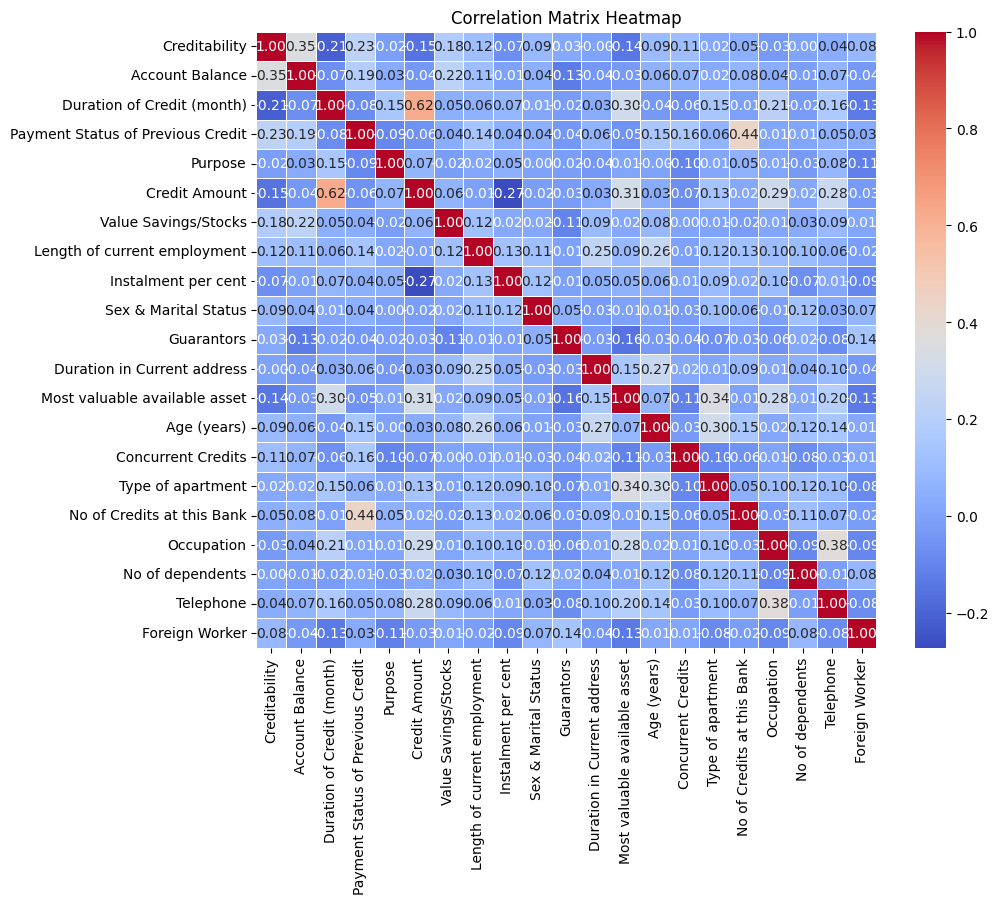

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix (numeric columns only)
corr_matrix = df.corr()

# Print correlation matrix
print("Correlation Matrix:\n", corr_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix (numeric columns only)
corr_matrix = df.corr()

# Print correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()
plt.show()

In [ ]:
print(df.columns)

Index(['Creditability', 'Account Balance', 'Duration of Credit (month)',
       'Payment Status of Previous Credit', 'Purpose', 'Credit Amount',
       'Value Savings/Stocks', 'Length of current employment',
       'Instalment per cent', 'Sex & Marital Status', 'Guarantors',
       'Duration in Current address', 'Most valuable available asset',
       'Age (years)', 'Concurrent Credits', 'Type of apartment',
       'No of Credits at this Bank', 'Occupation', 'No of dependents',
       'Telephone', 'Foreign Worker'],
      dtype='object')


Scale, Split and Preprocess the data set

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separate features and target
X = df.drop('Creditability', axis=1)
y = df['Creditability']

# Identify numeric and categorical features
numeric_features = ['Duration of Credit (month)', 'Credit Amount', 'Age (years)', 'Instalment per cent', 'No of Credits at this Bank', 'No of dependents']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Define transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit and transform X
X_transformed = preprocessor.fit_transform(X)

# Get new column names from the transformer
numeric_names = numeric_features
categorical_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_names) + list(categorical_names)

# Reconstruct the DataFrame
X_processed_df = pd.DataFrame(X_transformed, columns=all_feature_names, index=X.index)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.34, random_state=1)

# Apply SMOTE to training data
smote = SMOTE(random_state=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Optionally verify shapes after SMOTE
print(f"✅ Original training set shape: {X_train.shape}")
print(f"✅ After SMOTE training set shape: {X_train_smote.shape}")
print(f"🎯 Test set shape (unchanged): {X_test.shape}")



✅ Original training set shape: (660, 64)
✅ After SMOTE training set shape: (928, 64)
🎯 Test set shape (unchanged): (340, 64)


In [ ]:
# Check dimensions
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (660, 64)
X_test shape: (340, 64)
y_train shape: (660,)
y_test shape: (340,)


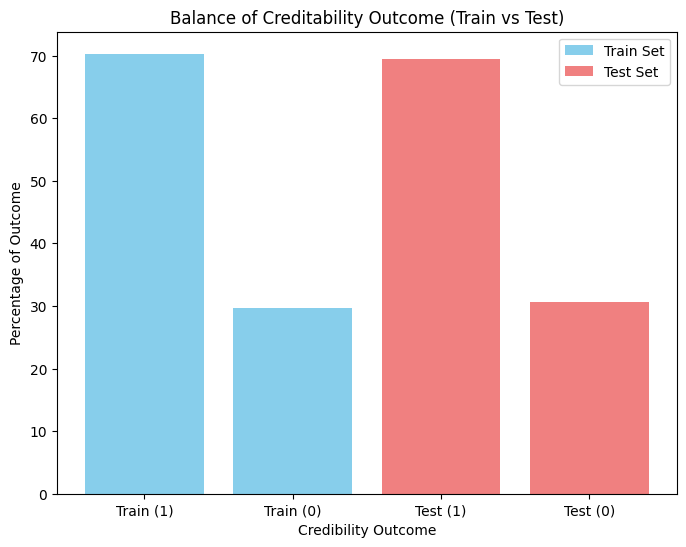

In [ ]:
import matplotlib.pyplot as plt
# Assuming y_train and y_test contain the credibility outcomes (0 or 1)
train_balance = y_train.value_counts(normalize=True) * 100
test_balance = y_test.value_counts(normalize=True) * 100

# Create the bar graph
plt.figure(figsize=(8, 6))
plt.bar(['Train (1)', 'Train (0)'], train_balance, label='Train Set', color='skyblue')
plt.bar(['Test (1)', 'Test (0)'], test_balance, label='Test Set', color='lightcoral')

plt.xlabel("Credibility Outcome")
plt.ylabel("Percentage of Outcome")
plt.title("Balance of Creditability Outcome (Train vs Test)")
plt.legend()
plt.show()


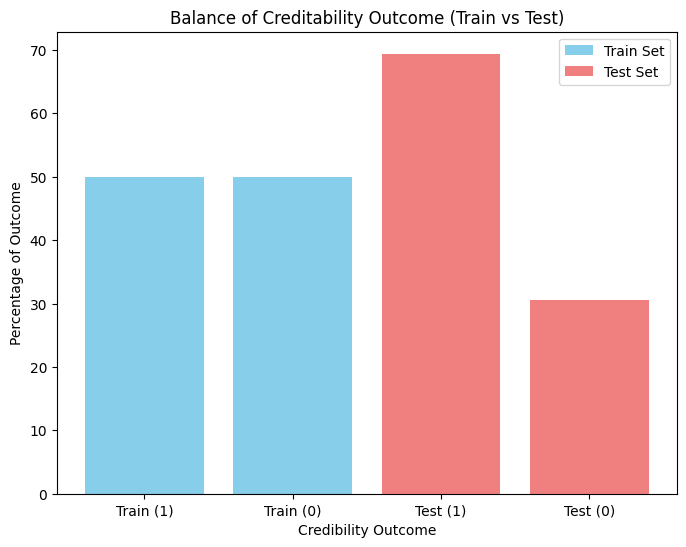

In [ ]:
import matplotlib.pyplot as plt
# Assuming y_train and y_test contain the credibility outcomes (0 or 1)
train_balance = y_train_smote.value_counts(normalize=True) * 100
test_balance = y_test.value_counts(normalize=True) * 100

# Create the bar graph
plt.figure(figsize=(8, 6))
plt.bar(['Train (1)', 'Train (0)'], train_balance, label='Train Set', color='skyblue')
plt.bar(['Test (1)', 'Test (0)'], test_balance, label='Test Set', color='lightcoral')

plt.xlabel("Credibility Outcome")
plt.ylabel("Percentage of Outcome")
plt.title("Balance of Creditability Outcome (Train vs Test)")
plt.legend()
plt.show()

Implement a Baseline Model (Saturated Logistic Regression with Baysian Optimization)

In [ ]:
!pip install scikit-optimize
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from skopt import gp_minimize
from skopt.space import Real, Categorical
import numpy as np

# Step 3: Define objective function for Bayesian Optimization
def objective(params):
    C, penalty = params
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
    score = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy').mean()
    return -score  # minimize negative accuracy

# Step 4: Define hyperparameter space
space = [
    Real(1e-6, 1e+6, prior='log-uniform', name='C'),
    Categorical(['l1', 'l2'], name='penalty')
]

# Step 5: Run Bayesian Optimization
result = gp_minimize(objective, space, n_calls=50, random_state=1)
best_C, best_penalty = result.x
best_solver = 'liblinear' if best_penalty == 'l1' else 'lbfgs'

# Step 6: Train final model using best parameters
final_model = LogisticRegression(C=best_C, penalty=best_penalty, solver=best_solver, max_iter=1000)
final_model.fit(X_train_smote, y_train_smote)

# Step 7: Evaluate and display classification report
y_pred = final_model.predict(X_test)
report = classification_report(y_test, y_pred)
print("📋 Classification Report:\n", report)

# Step 8: Display non-zero coefficients
if hasattr(final_model, 'coef_'):
    print("\n🔍 Non-zero Coefficients:")
    coef = final_model.coef_[0]
    feature_names = X_train.columns
    non_zero_count = 0
    for i, c in enumerate(coef):
        if c != 0:
            print(f"{feature_names[i]}: {c:.4f}")
            non_zero_count += 1
    print(f"\n🔢 Total Non-Zero Coefficients: {non_zero_count}")


📋 Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.73      0.59       104
           1       0.85      0.67      0.75       236

    accuracy                           0.69       340
   macro avg       0.67      0.70      0.67       340
weighted avg       0.74      0.69      0.70       340


🔍 Non-zero Coefficients:
Duration of Credit (month): -0.4717
Credit Amount: -0.1641
Age (years): 0.0969
Instalment per cent: -0.2219
No of Credits at this Bank: 0.0223
No of dependents: -0.1072
Account Balance_1: -0.5817
Account Balance_2: -0.2905
Account Balance_3: 0.1704
Account Balance_4: 1.1366
Payment Status of Previous Credit_0: -0.5769
Payment Status of Previous Credit_1: -0.3838
Payment Status of Previous Credit_3: 0.0027
Payment Status of Previous Credit_4: 0.3492
Purpose_0: -0.6869
Purpose_1: 0.6649
Purpose_5: -0.1727
Purpose_6: -0.5627
Value Savings/Stocks_1: -0.4810
Value Savings/Stocks_5: 0.1932
Length of current employment_2

Part 2: Logistic Regression with L1 regularization

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from skopt import gp_minimize
from skopt.space import Real
import numpy as np

# Step 2: Define objective function for L1 penalty only
def objective_l1_only(params):
    C = params[0]
    model = LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=2000)
    score = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring='accuracy').mean()
    return -score  # Minimize negative accuracy

# Step 3: Hyperparameter space (only C, L1 fixed)
space = [Real(1e-6, 1e6, prior='log-uniform', name='C')]

# Step 4: Run Bayesian optimization
result = gp_minimize(objective_l1_only, space, n_calls=50, random_state=1)
best_C = result.x[0]

# Step 5: Train final model with best C (L1)
final_model1 = LogisticRegression(C=best_C, penalty='l1', solver='liblinear', max_iter=2000)
final_model1.fit(X_train_smote, y_train_smote)

# Step 6: Evaluate and display classification report
y_pred = final_model1.predict(X_test)
report = classification_report(y_test, y_pred)
print("\n📋 Classification Report:")
print(report)

# Step 7: Display non-zero coefficients
coef = final_model1.coef_[0]
feature_names = X_train.columns

non_zero_features = [(feature_names[i], coef[i]) for i in range(len(coef)) if coef[i] != 0]

print("\n🔍 Non-zero Coefficients (Selected Features):")
for name, value in non_zero_features:
    print(f"{name}: {value:.4f}")

print(f"\n🔢 Total Non-zero Coefficients: {len(non_zero_features)}")
print(f"✅ Best C (L1): {best_C:.6f}")



📋 Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.73      0.59       104
           1       0.85      0.68      0.75       236

    accuracy                           0.69       340
   macro avg       0.68      0.70      0.67       340
weighted avg       0.74      0.69      0.71       340


🔍 Non-zero Coefficients (Selected Features):
Duration of Credit (month): -0.4689
Credit Amount: -0.1412
Age (years): 0.0994
Instalment per cent: -0.2109
No of Credits at this Bank: 0.0095
No of dependents: -0.0966
Account Balance_1: -0.6123
Account Balance_2: -0.3211
Account Balance_3: 0.0426
Account Balance_4: 1.0675
Payment Status of Previous Credit_0: -0.4564
Payment Status of Previous Credit_1: -0.2876
Payment Status of Previous Credit_4: 0.3574
Purpose_0: -0.6157
Purpose_1: 0.6008
Purpose_3: 0.0157
Purpose_6: -0.3840
Value Savings/Stocks_1: -0.4529
Value Savings/Stocks_5: 0.1701
Length of current employment_2: -0.4520
Length of curre

In [ ]:
print(non_zero_features)

[('Duration of Credit (month)', np.float64(-0.4688534910313964)), ('Credit Amount', np.float64(-0.14119085852715144)), ('Age (years)', np.float64(0.09941609088381946)), ('Instalment per cent', np.float64(-0.2108787255364813)), ('No of Credits at this Bank', np.float64(0.009487552620556524)), ('No of dependents', np.float64(-0.09658412064604077)), ('Account Balance_1', np.float64(-0.6122950788676138)), ('Account Balance_2', np.float64(-0.32113726068562376)), ('Account Balance_3', np.float64(0.042596127413976365)), ('Account Balance_4', np.float64(1.0675068661458966)), ('Payment Status of Previous Credit_0', np.float64(-0.45635702290634544)), ('Payment Status of Previous Credit_1', np.float64(-0.28761404757741327)), ('Payment Status of Previous Credit_4', np.float64(0.3574383248405387)), ('Purpose_0', np.float64(-0.6157495173166796)), ('Purpose_1', np.float64(0.6008239522069347)), ('Purpose_3', np.float64(0.015657666129700803)), ('Purpose_6', np.float64(-0.38401940197542395)), ('Value Sa

In [ ]:
# Define selected features based on non-zero L1 coefficients
selected_features = [feat for feat, coef in non_zero_features]

# Subset your original train/test sets to include only those features
X_train_selected = X_train_smote[selected_features]
X_test_selected  = X_test[selected_features]

# Quick check
print("✅ Selected features count:", len(selected_features))
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:",  X_test_selected.shape)


✅ Selected features count: 34
X_train_selected shape: (928, 34)
X_test_selected shape: (340, 34)


Part 3: Define a Best Classifier

Simulated a Money Impact using compounded Interest at 20% APR

# **Best Classifier based on Recall**


In [ ]:
from sklearn.metrics import recall_score, classification_report
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")


def best_classifier(X_train, X_test, y_train, y_test, df, LGD=0.6, annual_rate=0.20):
    """
    Trains multiple classifiers using Bayesian optimization (where applicable),
    evaluates recall, displays model-specific diagnostics (feature importances,
    decision tree for RandomForest, Naive Bayes discriminative features),
    and computes financial impact across all models with compounded monthly interest.

    Parameters:
        X_train, X_test, y_train, y_test: train/test splits
        df: original DataFrame containing 'Credit Amount' and 'Duration of Credit (month)'
        LGD: Loss Given Default (default 0.6)
        annual_rate: annual interest rate for good loans (default 0.20 for 20%)

    Returns:
        best_model: classifier with highest recall
        all_models: dict of all trained models
        money_impact_df: DataFrame summarizing financial impact per model
    """

    # Precompute monthly rate
    monthly_rate = annual_rate / 12

    # 1. Define models and hyperparameter spaces
    models = {
        'KNN': (KNeighborsClassifier(), {
            'n_neighbors': (1, 30),
            'weights': ['uniform', 'distance'],
            'p': (1, 2)
        }),
        'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'RandomForest': (RandomForestClassifier(random_state=42), {
            'n_estimators': (50, 300),
            'max_depth': (5, 50),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
            'n_estimators': (50, 300),
            'max_depth': (3, 20),
            'learning_rate': (0.01, 0.3, 'log-uniform'),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0)
        }),
        'NaiveBayes': (GaussianNB(), {})
    }

    best_scores = {}
    all_models = {}

    # 2. Train and tune each model
    for name, (model, params) in models.items():
        print(f"Tuning {name}...")

        if params:
            opt = BayesSearchCV(
                estimator=model,
                search_spaces=params,
                n_iter=20,
                scoring='recall_weighted',
                cv=3,
                n_jobs=-1,
                random_state=42
            )
            opt.fit(X_train, y_train)
            best_estimator = opt.best_estimator_
        else:
            model.fit(X_train, y_train)
            best_estimator = model

        # Evaluate recall on test set
        y_pred = best_estimator.predict(X_test)
        score = recall_score(y_test, y_pred, average='weighted')

        print(f"{name} Recall Score: {score:.4f}")
        best_scores[name] = (score, best_estimator)
        all_models[name] = best_estimator

    # 3. Identify best model
    best_model_name = max(best_scores, key=lambda k: best_scores[k][0])
    best_score, best_model = best_scores[best_model_name]

    print(f"\nBest Model: {best_model_name} with Recall Score: {best_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, best_model.predict(X_test)))

    # 4. RandomForest diagnostics
    if best_model_name == 'RandomForest':
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:3]
        print("\n🔥 Top 3 Feature Importances in Random Forest:")
        for idx in indices:
            print(f"{X_train.columns[idx]}: {importances[idx]:.4f}")

        estimator = best_model.estimators_[0]
        plt.figure(figsize=(20, 10))
        plot_tree(estimator, feature_names=X_train.columns, filled=True, rounded=True, max_depth=3)
        plt.title("🌳 Decision Tree from Random Forest (Trimmed to depth=3)")
        plt.show()

    # 5. Naive Bayes discriminative features
    if 'NaiveBayes' in all_models:
        nb_model = all_models['NaiveBayes']
        class_labels = nb_model.classes_
        means = pd.DataFrame(nb_model.theta_, columns=X_train.columns, index=class_labels)
        mean_diffs = means.diff().iloc[-1].abs().sort_values(ascending=False)
        top_features = mean_diffs.head(3)
        print("\n📊 Top 3 Naive Bayes Most Discriminative Features:")
        for feat, diff in top_features.items():
            print(f"{feat}: Δmean = {diff:.4f}")

    # 6. Financial impact evaluation with compounded monthly interest
    money_impact_list = []
    for model_name, model in all_models.items():
        print(f"\n💸 Evaluating money impact for model: {model_name}...")
        y_pred = model.predict(X_test)

        results_df = X_test.copy()
        results_df['true_label'] = y_test
        results_df['predicted_label'] = y_pred
        results_df['credit_amount'] = df.loc[X_test.index, 'Credit Amount']
        # Loan durations in months
        durations = df.loc[X_test.index, 'Duration of Credit (month)']

        # Label outcomes
        results_df['outcome'] = 'Unknown'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 0), 'outcome'] = 'TN'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 1), 'outcome'] = 'TP'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 1), 'outcome'] = 'FP'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 0), 'outcome'] = 'FN'

        # Compound interest calculation: principal * ((1 + monthly_rate)^n_months - 1)
        compounded = results_df['credit_amount'] * ((1 + monthly_rate) ** durations - 1)

        # Compute money impact
        results_df['money_impact'] = 0
        # FP: lose LGD * principal
        results_df.loc[results_df['outcome'] == 'FP', 'money_impact'] = -LGD * results_df['credit_amount']
        # FN: missed compounded interest
        results_df.loc[results_df['outcome'] == 'FN', 'money_impact'] = -compounded
        # TN: avoided LGD loss
        results_df.loc[results_df['outcome'] == 'TN', 'money_impact'] =  LGD * results_df['credit_amount']
        # TP: earned compounded interest
        results_df.loc[results_df['outcome'] == 'TP', 'money_impact'] =  compounded

        summary = results_df.groupby('outcome')['money_impact'].sum().reset_index()
        net = results_df['money_impact'].sum()

        money_impact_list.append({
            'Model': model_name,
            'Money Saved (TN)': summary.query("outcome=='TN'")['money_impact'].values[0] if 'TN' in summary['outcome'].values else 0,
            'Money Lost (FP)': summary.query("outcome=='FP'")['money_impact'].values[0] if 'FP' in summary['outcome'].values else 0,
            'Missed Profit (FN)': summary.query("outcome=='FN'")['money_impact'].values[0] if 'FN' in summary['outcome'].values else 0,
            'Net Impact': net
        })

    money_impact_df = pd.DataFrame(money_impact_list).sort_values(by='Net Impact', ascending=False)

    print("\n💰 Money Impact Comparison Across Models:")
    print(money_impact_df.to_string(index=False))

    # 7. Return all results
    return best_model, all_models, money_impact_df


Tuning KNN...
KNN Recall Score: 0.6265
Tuning DecisionTree...
DecisionTree Recall Score: 0.6676
Tuning RandomForest...
RandomForest Recall Score: 0.7471
Tuning XGBoost...
XGBoost Recall Score: 0.7324
Tuning NaiveBayes...
NaiveBayes Recall Score: 0.6912

Best Model: RandomForest with Recall Score: 0.7471

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.49      0.54       104
           1       0.79      0.86      0.83       236

    accuracy                           0.75       340
   macro avg       0.70      0.68      0.68       340
weighted avg       0.74      0.75      0.74       340


🔥 Top 3 Feature Importances in Random Forest:
Account Balance_4: 0.0997
Duration of Credit (month): 0.0900
Credit Amount: 0.0836


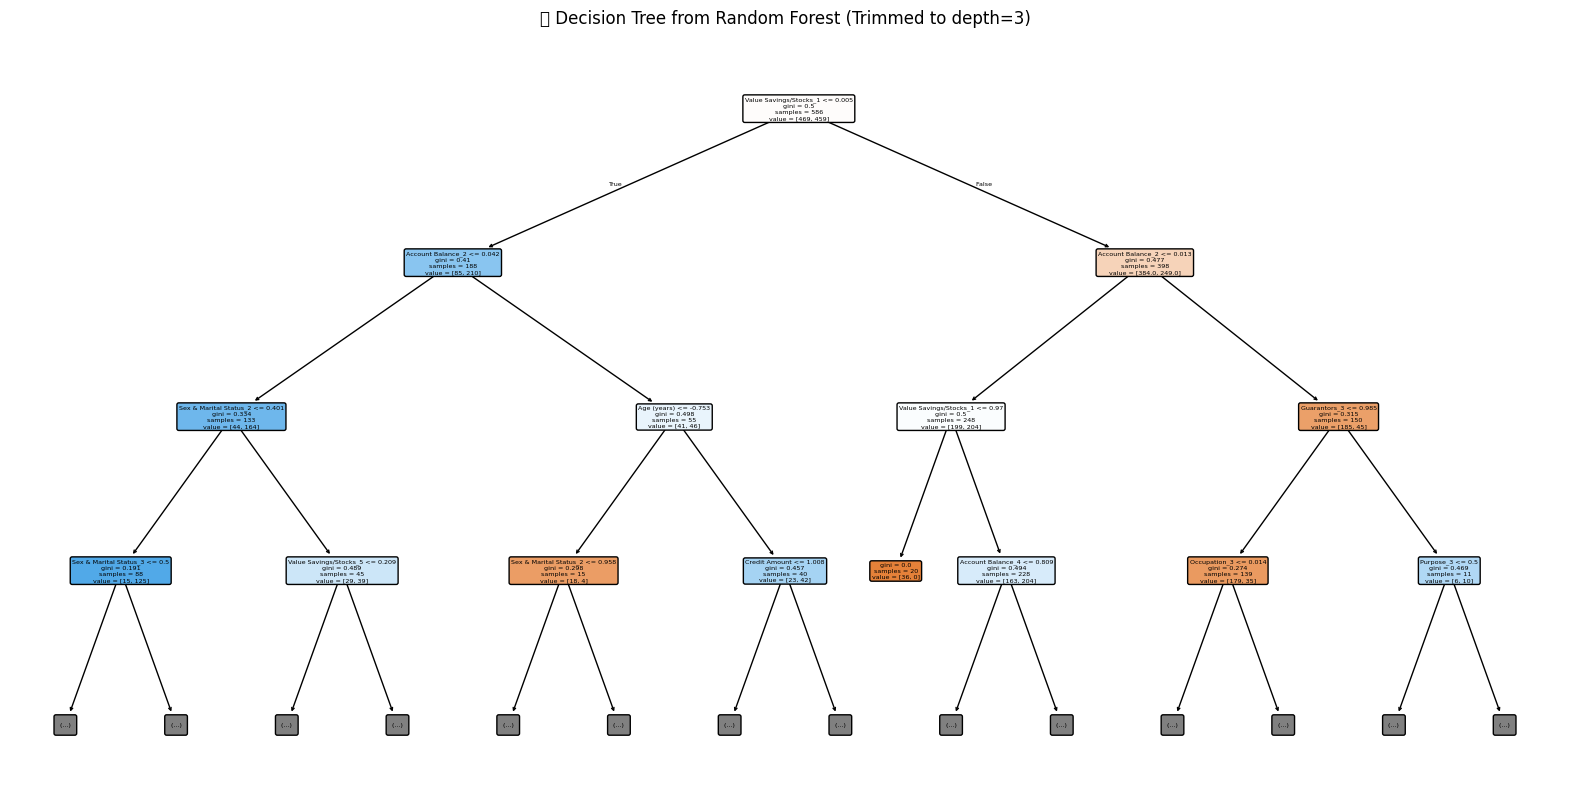


📊 Top 3 Naive Bayes Most Discriminative Features:
Duration of Credit (month): Δmean = 0.5768
Account Balance_4: Δmean = 0.3765
Credit Amount: Δmean = 0.3243

💸 Evaluating money impact for model: KNN...

💸 Evaluating money impact for model: DecisionTree...

💸 Evaluating money impact for model: RandomForest...

💸 Evaluating money impact for model: XGBoost...

💸 Evaluating money impact for model: NaiveBayes...

💰 Money Impact Comparison Across Models:
       Model  Money Saved (TN)  Money Lost (FP)  Missed Profit (FN)    Net Impact
RandomForest          139651.8         -93835.8       -99492.308190 268660.876219
     XGBoost          135469.8         -98017.8      -112579.804329 234121.883940
DecisionTree          144090.0         -89397.6      -160307.477442 155906.937714
  NaiveBayes          180017.4         -53470.2      -226007.469587  96361.753424
         KNN           94814.4        -138673.2      -151772.616686  74425.459227


In [ ]:
best_model, all_models, money_impact_df = best_classifier(
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test,
    df,            # your original DataFrame
    LGD=0.6,       # default loss given default
    annual_rate=0.20  # now using 20% annual rate
)


**Best Classifier based on Recall**
- We use this if we want to make the most money base off riskier borrowers.
- This could be in terms of penalty from delinquent payments.
- Exploitative but great for money making!
- Can improved further by focusing on Positive Recall - Sensitivity
- Note that for this, you will have a significantly better result in forcasting money impact if we have a panel data where we can track charges from delinquent payments.
- Broader implication on the entire financial market!!

# **Best Classifier based on Precision:**


In [ ]:
from sklearn.metrics import precision_score, classification_report
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

def best_classifier(X_train, X_test, y_train, y_test, df, LGD=0.6, annual_rate=0.20):
    """
    Trains multiple classifiers using Bayesian optimization (where applicable),
    evaluates precision, displays model-specific diagnostics (feature importances,
    decision tree for RandomForest, Naive Bayes discriminative features),
    and computes financial impact across all models with compounded monthly interest.

    Parameters:
        X_train, X_test, y_train, y_test: train/test splits
        df: original DataFrame containing 'Credit Amount' and 'Duration of Credit (month)'
        LGD: Loss Given Default (default 0.6)
        annual_rate: annual interest rate for good loans (default 0.20 for 20%)

    Returns:
        best_model: classifier with highest precision
        all_models: dict of all trained models
        money_impact_df: DataFrame summarizing financial impact per model
    """

    # Precompute monthly rate
    monthly_rate = annual_rate / 12

    # 1. Define models and hyperparameter spaces
    models = {
        'KNN': (KNeighborsClassifier(), {
            'n_neighbors': (1, 30),
            'weights': ['uniform', 'distance'],
            'p': (1, 2)
        }),
        'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'RandomForest': (RandomForestClassifier(random_state=42), {
            'n_estimators': (50, 300),
            'max_depth': (5, 50),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
            'n_estimators': (50, 300),
            'max_depth': (3, 20),
            'learning_rate': (0.01, 0.3, 'log-uniform'),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0)
        }),
        'NaiveBayes': (GaussianNB(), {})
    }

    best_scores = {}
    all_models = {}

    # 2. Train and tune each model
    for name, (model, params) in models.items():
        print(f"Tuning {name}...")

        if params:
            opt = BayesSearchCV(
                estimator=model,
                search_spaces=params,
                n_iter=20,
                scoring='precision_weighted',
                cv=3,
                n_jobs=-1,
                random_state=42
            )
            opt.fit(X_train, y_train)
            best_estimator = opt.best_estimator_
        else:
            model.fit(X_train, y_train)
            best_estimator = model

        # Evaluate precision on test set
        y_pred = best_estimator.predict(X_test)
        score = precision_score(y_test, y_pred, average='weighted')

        print(f"{name} Precision Score: {score:.4f}")
        best_scores[name] = (score, best_estimator)
        all_models[name] = best_estimator

    # 3. Identify best model
    best_model_name = max(best_scores, key=lambda k: best_scores[k][0])
    best_score, best_model = best_scores[best_model_name]

    print(f"\nBest Model: {best_model_name} with Precision Score: {best_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, best_model.predict(X_test)))

    # 4. RandomForest diagnostics
    if best_model_name == 'RandomForest':
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:3]
        print("\n🔥 Top 3 Feature Importances in Random Forest:")
        for idx in indices:
            print(f"{X_train.columns[idx]}: {importances[idx]:.4f}")

        estimator = best_model.estimators_[0]
        plt.figure(figsize=(20, 10))
        plot_tree(estimator, feature_names=X_train.columns, filled=True, rounded=True, max_depth=3)
        plt.title("🌳 Decision Tree from Random Forest (Trimmed to depth=3)")
        plt.show()

    # 5. Naive Bayes discriminative features
    if 'NaiveBayes' in all_models:
        nb_model = all_models['NaiveBayes']
        class_labels = nb_model.classes_
        means = pd.DataFrame(nb_model.theta_, columns=X_train.columns, index=class_labels)
        mean_diffs = means.diff().iloc[-1].abs().sort_values(ascending=False)
        top_features = mean_diffs.head(3)
        print("\n📊 Top 3 Naive Bayes Most Discriminative Features:")
        for feat, diff in top_features.items():
            print(f"{feat}: Δmean = {diff:.4f}")

    # 6. Financial impact evaluation with compounded monthly interest
    money_impact_list = []
    for model_name, model in all_models.items():
        print(f"\n💸 Evaluating money impact for model: {model_name}...")
        y_pred = model.predict(X_test)

        results_df = X_test.copy()
        results_df['true_label'] = y_test
        results_df['predicted_label'] = y_pred
        results_df['credit_amount'] = df.loc[X_test.index, 'Credit Amount']
        durations = df.loc[X_test.index, 'Duration of Credit (month)']

        results_df['outcome'] = 'Unknown'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 0), 'outcome'] = 'TN'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 1), 'outcome'] = 'TP'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 1), 'outcome'] = 'FP'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 0), 'outcome'] = 'FN'

        compounded = results_df['credit_amount'] * ((1 + monthly_rate) ** durations - 1)

        results_df['money_impact'] = 0
        results_df.loc[results_df['outcome'] == 'FP', 'money_impact'] = -LGD * results_df['credit_amount']
        results_df.loc[results_df['outcome'] == 'FN', 'money_impact'] = -compounded
        results_df.loc[results_df['outcome'] == 'TN', 'money_impact'] =  LGD * results_df['credit_amount']
        results_df.loc[results_df['outcome'] == 'TP', 'money_impact'] =  compounded

        summary = results_df.groupby('outcome')['money_impact'].sum().reset_index()
        net = results_df['money_impact'].sum()

        money_impact_list.append({
            'Model': model_name,
            'Money Saved (TN)': summary.query("outcome=='TN'")['money_impact'].values[0] if 'TN' in summary['outcome'].values else 0,
            'Money Lost (FP)': summary.query("outcome=='FP'")['money_impact'].values[0] if 'FP' in summary['outcome'].values else 0,
            'Missed Profit (FN)': summary.query("outcome=='FN'")['money_impact'].values[0] if 'FN' in summary['outcome'].values else 0,
            'Net Impact': net
        })

    money_impact_df = pd.DataFrame(money_impact_list).sort_values(by='Net Impact', ascending=False)

    print("\n💰 Money Impact Comparison Across Models:")
    print(money_impact_df.to_string(index=False))

    return best_model, all_models, money_impact_df


In [ ]:
best_model, all_models, money_impact_df = best_classifier(
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test,
    df,            # your original DataFrame
    LGD=0.6,       # default loss given default
    annual_rate=0.20  # now using 20% annual rate
)


Tuning KNN...
KNN Precision Score: 0.6214
Tuning DecisionTree...
DecisionTree Precision Score: 0.6894
Tuning RandomForest...
RandomForest Precision Score: 0.7271
Tuning XGBoost...
XGBoost Precision Score: 0.7117
Tuning NaiveBayes...
NaiveBayes Precision Score: 0.7395

Best Model: NaiveBayes with Precision Score: 0.7395

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.72      0.59       104
           1       0.85      0.68      0.75       236

    accuracy                           0.69       340
   macro avg       0.67      0.70      0.67       340
weighted avg       0.74      0.69      0.70       340


📊 Top 3 Naive Bayes Most Discriminative Features:
Duration of Credit (month): Δmean = 0.5768
Account Balance_4: Δmean = 0.3765
Credit Amount: Δmean = 0.3243

💸 Evaluating money impact for model: KNN...

💸 Evaluating money impact for model: DecisionTree...

💸 Evaluating money impact for model: RandomForest...

💸 Evaluating mon

**Best Classifier based on Precision:**
- Conservative Approach
- This is what we use if we care more about making sure that we dont loose out on default. High Loss Givenn Default
- Can be use when default
- Also, note that for precision , we care more about positive precision

# **Best Classifier Based on F1 Score**
- This is good for balance, since F1 is the Harmonic mean of both Precision and Recall

In [ ]:
from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

def best_classifier(X_train, X_test, y_train, y_test, df, LGD=0.6, annual_rate=0.20):
    """
    Trains multiple classifiers using Bayesian optimization (where applicable),
    evaluates F1 score, displays model-specific diagnostics (feature importances,
    decision tree for RandomForest, Naive Bayes discriminative features),
    and computes financial impact across all models with compounded monthly interest.

    Parameters:
        X_train, X_test, y_train, y_test: train/test splits
        df: original DataFrame containing 'Credit Amount' and 'Duration of Credit (month)'
        LGD: Loss Given Default (default 0.6)
        annual_rate: annual interest rate for good loans (default 0.20 for 20%)

    Returns:
        best_model: classifier with highest F1 score
        all_models: dict of all trained models
        money_impact_df: DataFrame summarizing financial impact per model
    """

    monthly_rate = annual_rate / 12

    models = {
        'KNN': (KNeighborsClassifier(), {
            'n_neighbors': (1, 30),
            'weights': ['uniform', 'distance'],
            'p': (1, 2)
        }),
        'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'RandomForest': (RandomForestClassifier(random_state=42), {
            'n_estimators': (50, 300),
            'max_depth': (5, 50),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
            'n_estimators': (50, 300),
            'max_depth': (3, 20),
            'learning_rate': (0.01, 0.3, 'log-uniform'),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0)
        }),
        'NaiveBayes': (GaussianNB(), {})
    }

    best_scores = {}
    all_models = {}

    for name, (model, params) in models.items():
        print(f"Tuning {name}...")

        if params:
            opt = BayesSearchCV(
                estimator=model,
                search_spaces=params,
                n_iter=20,
                scoring='f1_weighted',
                cv=3,
                n_jobs=-1,
                random_state=42
            )
            opt.fit(X_train, y_train)
            best_estimator = opt.best_estimator_
        else:
            model.fit(X_train, y_train)
            best_estimator = model

        y_pred = best_estimator.predict(X_test)
        score = f1_score(y_test, y_pred, average='weighted')

        print(f"{name} F1 Score: {score:.4f}")
        best_scores[name] = (score, best_estimator)
        all_models[name] = best_estimator

    best_model_name = max(best_scores, key=lambda k: best_scores[k][0])
    best_score, best_model = best_scores[best_model_name]

    print(f"\n✅ Best Model: {best_model_name} with F1 Score: {best_score:.4f}")
    print("\n📋 Classification Report (Test Set):")
    print(classification_report(y_test, best_model.predict(X_test)))

    if best_model_name == 'RandomForest':
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:3]
        print("\n🔥 Top 3 Feature Importances in Random Forest:")
        for idx in indices:
            print(f"{X_train.columns[idx]}: {importances[idx]:.4f}")

        estimator = best_model.estimators_[0]
        plt.figure(figsize=(20, 10))
        plot_tree(estimator, feature_names=X_train.columns, filled=True, rounded=True, max_depth=3)
        plt.title("🌳 Decision Tree from Random Forest (Trimmed to depth=3)")
        plt.show()

    if 'NaiveBayes' in all_models:
        nb_model = all_models['NaiveBayes']
        class_labels = nb_model.classes_
        means = pd.DataFrame(nb_model.theta_, columns=X_train.columns, index=class_labels)
        mean_diffs = means.diff().iloc[-1].abs().sort_values(ascending=False)
        top_features = mean_diffs.head(3)
        print("\n📊 Top 3 Naive Bayes Most Discriminative Features:")
        for feat, diff in top_features.items():
            print(f"{feat}: Δmean = {diff:.4f}")

    money_impact_list = []
    for model_name, model in all_models.items():
        print(f"\n💸 Evaluating money impact for model: {model_name}...")
        y_pred = model.predict(X_test)

        results_df = X_test.copy()
        results_df['true_label'] = y_test
        results_df['predicted_label'] = y_pred
        results_df['credit_amount'] = df.loc[X_test.index, 'Credit Amount']
        durations = df.loc[X_test.index, 'Duration of Credit (month)']

        results_df['outcome'] = 'Unknown'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 0), 'outcome'] = 'TN'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 1), 'outcome'] = 'TP'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 1), 'outcome'] = 'FP'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 0), 'outcome'] = 'FN'

        compounded = results_df['credit_amount'] * ((1 + monthly_rate) ** durations - 1)

        results_df['money_impact'] = 0
        results_df.loc[results_df['outcome'] == 'FP', 'money_impact'] = -LGD * results_df['credit_amount']
        results_df.loc[results_df['outcome'] == 'FN', 'money_impact'] = -compounded
        results_df.loc[results_df['outcome'] == 'TN', 'money_impact'] =  LGD * results_df['credit_amount']
        results_df.loc[results_df['outcome'] == 'TP', 'money_impact'] =  compounded

        summary = results_df.groupby('outcome')['money_impact'].sum().reset_index()
        net = results_df['money_impact'].sum()

        money_impact_list.append({
            'Model': model_name,
            'Money Saved (TN)': summary.query("outcome=='TN'")['money_impact'].values[0] if 'TN' in summary['outcome'].values else 0,
            'Money Lost (FP)': summary.query("outcome=='FP'")['money_impact'].values[0] if 'FP' in summary['outcome'].values else 0,
            'Missed Profit (FN)': summary.query("outcome=='FN'")['money_impact'].values[0] if 'FN' in summary['outcome'].values else 0,
            'Net Impact': net
        })

    money_impact_df = pd.DataFrame(money_impact_list).sort_values(by='Net Impact', ascending=False)

    print("\n💰 Money Impact Comparison Across Models:")
    print(money_impact_df.to_string(index=False))

    return best_model, all_models, money_impact_df


In [ ]:
best_model, all_models, money_impact_df = best_classifier(
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test,
    df,            # your original DataFrame
    LGD=0.6,       # default loss given default
    annual_rate=0.20  # now using 20% annual rate
)


Tuning KNN...
KNN F1 Score: 0.6238
Tuning DecisionTree...
DecisionTree F1 Score: 0.6720
Tuning RandomForest...
RandomForest F1 Score: 0.7356
Tuning XGBoost...
XGBoost F1 Score: 0.7399
Tuning NaiveBayes...
NaiveBayes F1 Score: 0.7026

✅ Best Model: XGBoost with F1 Score: 0.7399

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.59      0.53      0.56       104
           1       0.80      0.84      0.82       236

    accuracy                           0.74       340
   macro avg       0.70      0.68      0.69       340
weighted avg       0.74      0.74      0.74       340


📊 Top 3 Naive Bayes Most Discriminative Features:
Duration of Credit (month): Δmean = 0.5768
Account Balance_4: Δmean = 0.3765
Credit Amount: Δmean = 0.3243

💸 Evaluating money impact for model: KNN...

💸 Evaluating money impact for model: DecisionTree...

💸 Evaluating money impact for model: RandomForest...

💸 Evaluating money impact for model: XGBoost..

Analysis with PR-Curve Widget

In [ ]:
from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

def best_classifier(X_train, X_test, y_train, y_test, df, LGD=0.6, annual_rate=0.20):
    """
    Trains multiple classifiers using Bayesian optimization,
    evaluates them using F1 score at default threshold 0.5,
    computes financial impact,
    and returns prediction probabilities for threshold analysis.

    Returns:
        best_model: classifier with highest F1 score at threshold 0.5
        all_models: dict of all trained models
        money_impact_df: DataFrame summarizing financial impact per model
        y_probs_dict: dict of predicted probabilities per model (for class 1)
    """

    monthly_rate = annual_rate / 12
    y_probs_dict = {}  # Stores predicted probabilities for each model

    models = {
        'KNN': (KNeighborsClassifier(), {
            'n_neighbors': (1, 30),
            'weights': ['uniform', 'distance'],
            'p': (1, 2)
        }),
        'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'RandomForest': (RandomForestClassifier(random_state=42), {
            'n_estimators': (50, 300),
            'max_depth': (5, 50),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
            'n_estimators': (50, 300),
            'max_depth': (3, 20),
            'learning_rate': (0.01, 0.3, 'log-uniform'),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0)
        }),
        'NaiveBayes': (GaussianNB(), {})
    }

    best_scores = {}
    all_models = {}

    for name, (model, params) in models.items():
        print(f"Tuning {name}...")

        if params:
            opt = BayesSearchCV(
                estimator=model,
                search_spaces=params,
                n_iter=20,
                scoring='f1_weighted',
                cv=3,
                n_jobs=-1,
                random_state=42
            )
            opt.fit(X_train, y_train)
            best_estimator = opt.best_estimator_
        else:
            model.fit(X_train, y_train)
            best_estimator = model

        # Predict probabilities for positive class
        y_probs = best_estimator.predict_proba(X_test)[:, 1]
        y_pred = (y_probs >= 0.5).astype(int)  # Use threshold = 0.5 for evaluation

        score = f1_score(y_test, y_pred, average='weighted')
        y_probs_dict[name] = y_probs  # Save predicted probabilities
        best_scores[name] = (score, best_estimator)
        all_models[name] = best_estimator

        print(f"{name} F1 Score: {score:.4f}")

    # Identify best model based on F1 score
    best_model_name = max(best_scores, key=lambda k: best_scores[k][0])
    best_score, best_model = best_scores[best_model_name]

    print(f"\n✅ Best Model: {best_model_name} with F1 Score: {best_score:.4f}")
    print("\n📋 Classification Report (Test Set):")
    print(classification_report(y_test, best_model.predict(X_test)))

    # Calculate financial impact at threshold 0.5
    money_impact_list = []
    for model_name, model in all_models.items():
        print(f"\n💸 Evaluating money impact for model: {model_name}...")
        y_probs = y_probs_dict[model_name]
        y_pred = (y_probs >= 0.5).astype(int)

        results_df = X_test.copy()
        results_df['true_label'] = y_test
        results_df['predicted_label'] = y_pred
        results_df['credit_amount'] = df.loc[X_test.index, 'Credit Amount']
        durations = df.loc[X_test.index, 'Duration of Credit (month)']

        results_df['outcome'] = 'Unknown'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 0), 'outcome'] = 'TN'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 1), 'outcome'] = 'TP'
        results_df.loc[(results_df['true_label'] == 0) & (results_df['predicted_label'] == 1), 'outcome'] = 'FP'
        results_df.loc[(results_df['true_label'] == 1) & (results_df['predicted_label'] == 0), 'outcome'] = 'FN'

        compounded = results_df['credit_amount'] * ((1 + monthly_rate) ** durations - 1)
        results_df['money_impact'] = 0
        results_df.loc[results_df['outcome'] == 'FP', 'money_impact'] = -LGD * results_df['credit_amount']
        results_df.loc[results_df['outcome'] == 'FN', 'money_impact'] = -compounded
        results_df.loc[results_df['outcome'] == 'TN', 'money_impact'] =  LGD * results_df['credit_amount']
        results_df.loc[results_df['outcome'] == 'TP', 'money_impact'] =  compounded

        summary = results_df.groupby('outcome')['money_impact'].sum().reset_index()
        net = results_df['money_impact'].sum()

        money_impact_list.append({
            'Model': model_name,
            'Money Saved (TN)': summary.query("outcome=='TN'")['money_impact'].values[0] if 'TN' in summary['outcome'].values else 0,
            'Money Lost (FP)': summary.query("outcome=='FP'")['money_impact'].values[0] if 'FP' in summary['outcome'].values else 0,
            'Missed Profit (FN)': summary.query("outcome=='FN'")['money_impact'].values[0] if 'FN' in summary['outcome'].values else 0,
            'Net Impact': net
        })

    money_impact_df = pd.DataFrame(money_impact_list).sort_values(by='Net Impact', ascending=False)

    print("\n💰 Money Impact Comparison Across Models:")
    print(money_impact_df.to_string(index=False))

    return best_model, all_models, money_impact_df, y_probs_dict


In [ ]:
best_model, all_models, money_impact_df, y_probs_dict = best_classifier(X_train_selected, X_test_selected, y_train_smote, y_test, df)


Tuning KNN...
KNN F1 Score: 0.6238
Tuning DecisionTree...
DecisionTree F1 Score: 0.6891
Tuning RandomForest...
RandomForest F1 Score: 0.7356
Tuning XGBoost...
XGBoost F1 Score: 0.7399
Tuning NaiveBayes...
NaiveBayes F1 Score: 0.7026

✅ Best Model: XGBoost with F1 Score: 0.7399

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.59      0.53      0.56       104
           1       0.80      0.84      0.82       236

    accuracy                           0.74       340
   macro avg       0.70      0.68      0.69       340
weighted avg       0.74      0.74      0.74       340


💸 Evaluating money impact for model: KNN...

💸 Evaluating money impact for model: DecisionTree...

💸 Evaluating money impact for model: RandomForest...

💸 Evaluating money impact for model: XGBoost...

💸 Evaluating money impact for model: NaiveBayes...

💰 Money Impact Comparison Across Models:
       Model  Money Saved (TN)  Money Lost (FP)  Missed Profit

In [ ]:
list(y_probs_dict.keys())


['KNN', 'DecisionTree', 'RandomForest', 'XGBoost', 'NaiveBayes']

In [ ]:
y_probs_dict['XGBoost'][:5]  # Preview first 5 probabilities


array([0.9496225 , 0.83836585, 0.33174077, 0.20770602, 0.73096275],
      dtype=float32)

In [ ]:
pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.6 MB/s eta 0:00:00


In [ ]:
from google.colab import output
output.enable_custom_widget_manager()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown

# Pull your actual values:
y_true = y_test.values
credit_amount = df.loc[X_test.index, 'Credit Amount'].values
duration_months = df.loc[X_test.index, 'Duration of Credit (month)'].values
y_probs = y_probs_dict  # <-- Real model probabilities

LGD = 0.6
monthly_rate = 0.20 / 12

def evaluate_costs(threshold, model_name):
    probs = y_probs[model_name]
    y_pred = (probs >= threshold).astype(int)

    results = pd.DataFrame({
        'true_label': y_true,
        'predicted_label': y_pred,
        'credit_amount': credit_amount,
        'duration': duration_months
    })

    results['outcome'] = 'Unknown'
    results.loc[(results['true_label'] == 0) & (results['predicted_label'] == 0), 'outcome'] = 'TN'
    results.loc[(results['true_label'] == 1) & (results['predicted_label'] == 1), 'outcome'] = 'TP'
    results.loc[(results['true_label'] == 0) & (results['predicted_label'] == 1), 'outcome'] = 'FP'
    results.loc[(results['true_label'] == 1) & (results['predicted_label'] == 0), 'outcome'] = 'FN'

    compounded = results['credit_amount'] * ((1 + monthly_rate) ** results['duration'] - 1)
    results['money_impact'] = 0
    results.loc[results['outcome'] == 'FP', 'money_impact'] = -LGD * results['credit_amount']
    results.loc[results['outcome'] == 'FN', 'money_impact'] = -compounded
    results.loc[results['outcome'] == 'TN', 'money_impact'] =  LGD * results['credit_amount']
    results.loc[results['outcome'] == 'TP', 'money_impact'] =  compounded

    impact_summary = results.groupby('outcome')['money_impact'].sum().to_dict()
    net_impact = results['money_impact'].sum()

    print(f"\n💼 Model: {model_name} | Threshold: {threshold:.2f}")
    print(f"✅ TN impact: ${impact_summary.get('TN', 0):,.2f}")
    print(f"✅ TP impact: ${impact_summary.get('TP', 0):,.2f}")
    print(f"❌ FP loss:   ${impact_summary.get('FP', 0):,.2f}")
    print(f"❌ FN loss:   ${impact_summary.get('FN', 0):,.2f}")
    print(f"\n💰 Net Financial Impact: ${net_impact:,.2f}")

    outcome_counts = results['outcome'].value_counts()
    outcome_counts.plot(kind='bar', color='skyblue', title='Outcome Counts')
    plt.xticks(rotation=0)
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.show()

interact(
    evaluate_costs,
    threshold=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description='Threshold'),
    model_name=Dropdown(options=list(y_probs.keys()), value=list(y_probs.keys())[0], description='Model')
);


interactive(children=(FloatSlider(value=0.5, description='Threshold', max=1.0, step=0.05), Dropdown(descriptio…

**⚙️ STEP 1: Cross-Validation of Thresholds for Cost Minimization
We'll:**

Use Stratified KFold to keep class balance

For each fold:

Train the model

Get predicted probabilities

Sweep thresholds from 0 → 1

Calculate net money impact

Average across folds to find the most robust threshold

**📈 STEP 2: Plot Cost vs Threshold
We'll:**

Aggregate cost across folds for each threshold

Plot it to visualize the "valley" of optimal financial gain

Identify and label the best threshold

**🚀 STEP 3: Threshold Scheduling Logic for Deployment
We'll build:**

A small utility function:

python
Copy
Edit
def schedule_threshold(business_cycle='Q2', volatility_level='high'):
    # logic for choosing threshold dynamically
Inputs can be:

Time of year

Risk exposure preference

Market signals

Output: recommended threshold to use



In [ ]:
# Use preprocessed, but not SMOTE-applied data
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_processed_df[selected_features], y, test_size=0.34, random_state=1
)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

def cross_validate_thresholds_for_cost(
    X, y, model, df,
    n_splits=5,
    thresholds=np.arange(0.05, 1.0, 0.05),
    LGD=0.6,
    annual_rate=0.20
):
    """
    Perform cross-validation to determine the best classification threshold for minimizing cost.

    Parameters:
        X, y: Input features and target
        model: Classifier supporting predict_proba()
        df: Original DataFrame to extract financial columns
        n_splits: Number of Stratified CV folds
        thresholds: Array of thresholds to evaluate
        LGD: Loss Given Default (default: 0.6)
        annual_rate: Annual interest rate (default: 0.20)

    Returns:
        cost_df: DataFrame with average net impact per threshold
        best_threshold: Threshold with the highest average net gain
    """
    monthly_rate = annual_rate / 12
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    threshold_costs = {t: [] for t in thresholds}

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
        df_test_fold = df.iloc[test_idx]

        # Apply SMOTE inside the fold
        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train_fold, y_train_fold)

        # Fit model
        model.fit(X_train_res, y_train_res)
        y_probs = model.predict_proba(X_test_fold)[:, 1]

        credit_amount = df_test_fold['Credit Amount'].values
        duration_months = df_test_fold['Duration of Credit (month)'].values

        for t in thresholds:
            y_pred = (y_probs >= t).astype(int)
            outcome = np.full_like(y_test_fold, 'Unknown', dtype=object)
            outcome[(y_test_fold == 0) & (y_pred == 0)] = 'TN'
            outcome[(y_test_fold == 1) & (y_pred == 1)] = 'TP'
            outcome[(y_test_fold == 0) & (y_pred == 1)] = 'FP'
            outcome[(y_test_fold == 1) & (y_pred == 0)] = 'FN'

            compounded = credit_amount * ((1 + monthly_rate) ** duration_months - 1)
            money_impact = np.zeros_like(credit_amount)

            money_impact[outcome == 'FP'] = -LGD * credit_amount[outcome == 'FP']
            money_impact[outcome == 'FN'] = -compounded[outcome == 'FN']
            money_impact[outcome == 'TN'] =  LGD * credit_amount[outcome == 'TN']
            money_impact[outcome == 'TP'] =  compounded[outcome == 'TP']

            total_cost = np.sum(money_impact)
            threshold_costs[t].append(total_cost)

    # Aggregate results
    cost_df = pd.DataFrame({
        'Threshold': list(threshold_costs.keys()),
        'Avg_Net_Impact': [np.mean(threshold_costs[t]) for t in thresholds],
        'Std_Dev': [np.std(threshold_costs[t]) for t in thresholds]
    }).sort_values(by='Avg_Net_Impact', ascending=False)

    best_threshold = cost_df.iloc[0]['Threshold']

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(cost_df['Threshold'], cost_df['Avg_Net_Impact'], marker='o', label='Average Net Impact')
    plt.fill_between(cost_df['Threshold'],
                     cost_df['Avg_Net_Impact'] - cost_df['Std_Dev'],
                     cost_df['Avg_Net_Impact'] + cost_df['Std_Dev'],
                     alpha=0.2, label='±1 Std Dev')
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
    plt.title('💰 Expected Cost vs. Threshold (Cross-Validated)')
    plt.xlabel('Decision Threshold')
    plt.ylabel('Average Net Financial Impact')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cost_df, best_threshold


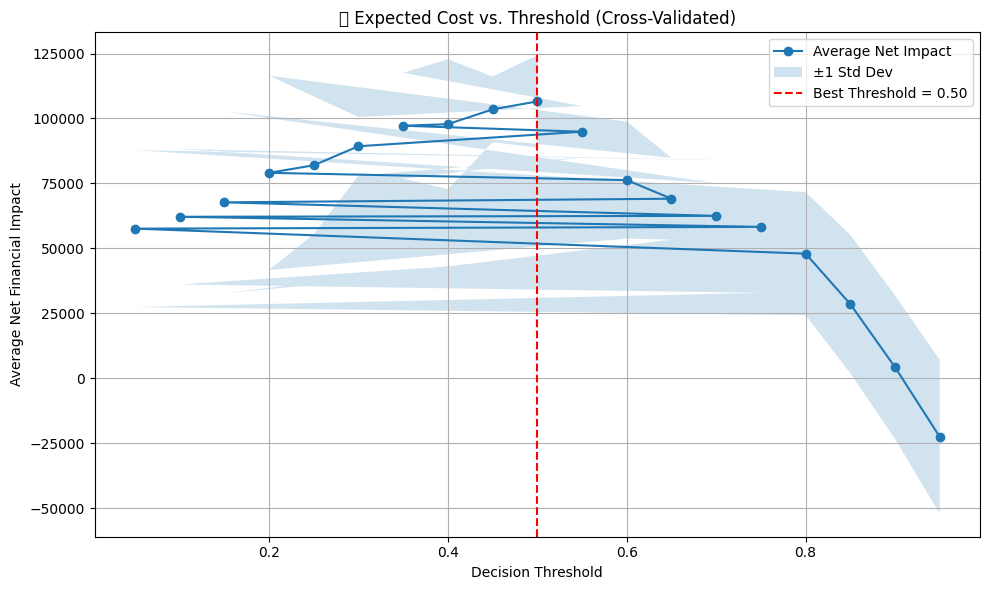

In [ ]:
xgb_model = all_models['XGBoost']

cost_df, best_thresh = cross_validate_thresholds_for_cost(
    X=X_train_clean,
    y=y_train_clean,
    model=xgb_model,
    df=df.loc[X_train_clean.index]  # so we get the original credit/duration
)

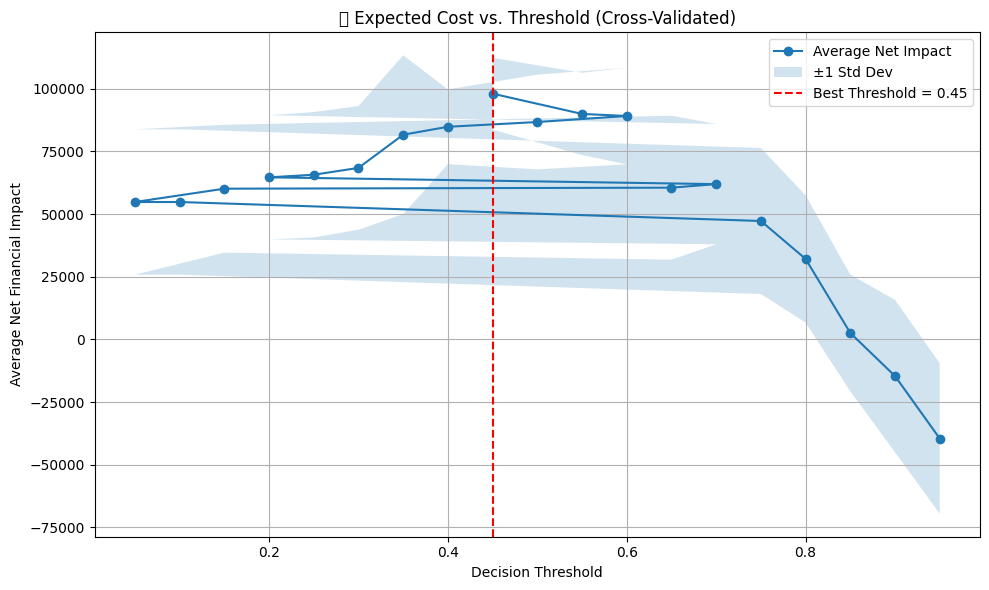

In [ ]:
rf_model = all_models['RandomForest']

cost_df, best_thresh = cross_validate_thresholds_for_cost(
    X=X_train_clean,
    y=y_train_clean,
    model=rf_model,
    df=df.loc[X_train_clean.index]  # so we get the original credit/duration
)


# **Best Classifier Based on Negative Recall (Specificity)**

In [ ]:
from sklearn.metrics import recall_score, classification_report, make_scorer
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# 1. Define a scorer for negative-class recall (specificity) - prioritize predicting bad borrowers
neg_recall_scorer = make_scorer(recall_score, pos_label=0)

def best_classifier(X_train, X_test, y_train, y_test, df, LGD=0.6, annual_rate=0.20):
    """
    Trains multiple classifiers using Bayesian optimization (where applicable),
    evaluates Negative Recall (specificity), displays model diagnostics,
    and computes financial impact with compounded monthly interest.
    """
    # Precompute monthly rate
    monthly_rate = annual_rate / 12

    # 2. Define models and hyperparameter spaces
    models = {
        'KNN': (KNeighborsClassifier(), {
            'n_neighbors': (1, 30),
            'weights': ['uniform', 'distance'],
            'p': (1, 2)
        }),
        'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'RandomForest': (RandomForestClassifier(random_state=42), {
            'n_estimators': (50, 300),
            'max_depth': (5, 50),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
            'n_estimators': (50, 300),
            'max_depth': (3, 20),
            'learning_rate': (0.01, 0.3, 'log-uniform'),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0)
        }),
        'NaiveBayes': (GaussianNB(), {})
    }

    best_scores = {}
    all_models = {}

    # 3. Train, tune, and evaluate each model on Negative Recall
    for name, (model, params) in models.items():
        print(f"Tuning {name} (negative recall)...")

        if params:
            opt = BayesSearchCV(
                estimator=model,
                search_spaces=params,
                n_iter=20,
                scoring=neg_recall_scorer,    # use negative-class recall
                cv=3,
                n_jobs=-1,
                random_state=42
            )
            opt.fit(X_train, y_train)
            best_estimator = opt.best_estimator_
        else:
            model.fit(X_train, y_train)
            best_estimator = model

        # Compute negative recall on test set
        y_pred = best_estimator.predict(X_test)
        neg_recall = recall_score(y_test, y_pred, pos_label=0)

        print(f"{name} Negative Recall: {neg_recall:.4f}")
        best_scores[name] = (neg_recall, best_estimator)
        all_models[name] = best_estimator

    # 4. Identify best model by highest negative recall
    best_model_name = max(best_scores, key=lambda k: best_scores[k][0])
    best_neg_recall, best_model = best_scores[best_model_name]

    print(f"\nBest Model: {best_model_name} with Negative Recall: {best_neg_recall:.4f}")
    print("\nClassification Report (showing both classes):")
    print(classification_report(y_test, best_model.predict(X_test)))

    # 5. RandomForest diagnostics (if selected)
    if best_model_name == 'RandomForest':
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:3]
        print("\n🔥 Top 3 Feature Importances in Random Forest:")
        for idx in indices:
            print(f"{X_train.columns[idx]}: {importances[idx]:.4f}")

        plt.figure(figsize=(20, 10))
        plot_tree(best_model.estimators_[0],
                  feature_names=X_train.columns,
                  filled=True, rounded=True, max_depth=3)
        plt.title("🌳 Sample Tree from Random Forest (depth=3)")
        plt.show()

    # 6. Naive Bayes discriminative features
    if 'NaiveBayes' in all_models:
        nb = all_models['NaiveBayes']
        labels = nb.classes_
        means = pd.DataFrame(nb.theta_, columns=X_train.columns, index=labels)
        diffs = means.diff().iloc[-1].abs().sort_values(ascending=False).head(3)
        print("\n📊 Top 3 Naive Bayes Discriminative Features:")
        for feat, diff in diffs.items():
            print(f"{feat}: Δmean = {diff:.4f}")

    # 7. Financial impact evaluation (unchanged)
    money_impact_list = []
    for model_name, model in all_models.items():
        print(f"\n💸 Evaluating money impact for: {model_name}...")
        y_pred = model.predict(X_test)

        results = X_test.copy()
        results['true'] = y_test
        results['pred'] = y_pred
        results['amt'] = df.loc[X_test.index, 'Credit Amount']
        durations = df.loc[X_test.index, 'Duration of Credit (month)']

        # Label outcomes
        mask_TN = (results['true']==0)&(results['pred']==0)
        mask_FP = (results['true']==0)&(results['pred']==1)
        mask_FN = (results['true']==1)&(results['pred']==0)
        mask_TP = (results['true']==1)&(results['pred']==1)

        # Compound interest
        comp = results['amt'] * ((1+monthly_rate)**durations - 1)

        results['impact'] = 0
        results.loc[mask_TN, 'impact'] =  LGD * results.loc[mask_TN, 'amt']
        results.loc[mask_FP, 'impact'] = -LGD * results.loc[mask_FP, 'amt']
        results.loc[mask_FN, 'impact'] = -comp[mask_FN]
        results.loc[mask_TP, 'impact'] =  comp[mask_TP]

        summary = results.groupby(lambda i: (
            'TN' if mask_TN[i] else
            'FP' if mask_FP[i] else
            'FN' if mask_FN[i] else
            'TP'
        ))['impact'].sum().reset_index(name='money')

        net = results['impact'].sum()
        money_impact_list.append({
            'Model': model_name,
            **{f"{row['index']} Impact": row['money'] for _, row in summary.iterrows()},
            'Net Impact': net
        })

    money_impact_df = pd.DataFrame(money_impact_list).fillna(0)
    print("\n💰 Money Impact Comparison:")
    print(money_impact_df.to_string(index=False))

    return best_model, all_models, money_impact_df


In [ ]:
best_model, all_models, money_impact_df = best_classifier(
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test,
    df,            # your original DataFrame
    LGD=0.6,       # default loss given default
    annual_rate=0.20  # now using 20% annual rate
)


Tuning KNN (negative recall)...
KNN Negative Recall: 0.6154
Tuning DecisionTree (negative recall)...
DecisionTree Negative Recall: 0.8558
Tuning RandomForest (negative recall)...
RandomForest Negative Recall: 0.6731
Tuning XGBoost (negative recall)...
XGBoost Negative Recall: 0.7981
Tuning NaiveBayes (negative recall)...
NaiveBayes Negative Recall: 0.7212

Best Model: DecisionTree with Negative Recall: 0.8558

Classification Report (showing both classes):
              precision    recall  f1-score   support

           0       0.42      0.86      0.56       104
           1       0.88      0.47      0.62       236

    accuracy                           0.59       340
   macro avg       0.65      0.67      0.59       340
weighted avg       0.74      0.59      0.60       340


📊 Top 3 Naive Bayes Discriminative Features:
Duration of Credit (month): Δmean = 0.5768
Account Balance_4: Δmean = 0.3765
Credit Amount: Δmean = 0.3243

💸 Evaluating money impact for: KNN...

💸 Evaluating money i

# Best Classifier based on Positive Recall (Sensitivity)

In [ ]:
from sklearn.metrics import recall_score, classification_report, make_scorer
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# 1. Define a scorer for positive-class recall (sensitivity)
pos_recall_scorer = make_scorer(recall_score, pos_label=1)

def best_classifier(X_train, X_test, y_train, y_test, df, LGD=0.6, annual_rate=0.20):
    """
    Trains multiple classifiers using Bayesian optimization (where applicable),
    evaluates Positive Recall (sensitivity), displays model diagnostics,
    and computes financial impact with compounded monthly interest.
    """
    # Precompute monthly rate
    monthly_rate = annual_rate / 12

    # 2. Define models and hyperparameter spaces
    models = {
        'KNN': (KNeighborsClassifier(), {
            'n_neighbors': (1, 30),
            'weights': ['uniform', 'distance'],
            'p': (1, 2)
        }),
        'DecisionTree': (DecisionTreeClassifier(random_state=42), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'RandomForest': (RandomForestClassifier(random_state=42), {
            'n_estimators': (50, 300),
            'max_depth': (5, 50),
            'min_samples_split': (2, 10),
            'criterion': ['gini', 'entropy']
        }),
        'XGBoost': (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), {
            'n_estimators': (50, 300),
            'max_depth': (3, 20),
            'learning_rate': (0.01, 0.3, 'log-uniform'),
            'subsample': (0.5, 1.0),
            'colsample_bytree': (0.5, 1.0)
        }),
        'NaiveBayes': (GaussianNB(), {})
    }

    best_scores = {}
    all_models = {}

    # 3. Train, tune, and evaluate each model on Positive Recall
    for name, (model, params) in models.items():
        print(f"Tuning {name} (positive recall)...")

        if params:
            opt = BayesSearchCV(
                estimator=model,
                search_spaces=params,
                n_iter=20,
                scoring=pos_recall_scorer,    # use positive-class recall
                cv=3,
                n_jobs=-1,
                random_state=42
            )
            opt.fit(X_train, y_train)
            best_estimator = opt.best_estimator_
        else:
            model.fit(X_train, y_train)
            best_estimator = model

        # Compute positive recall on test set
        y_pred = best_estimator.predict(X_test)
        pos_recall = recall_score(y_test, y_pred, pos_label=1)

        print(f"{name} Positive Recall: {pos_recall:.4f}")
        best_scores[name] = (pos_recall, best_estimator)
        all_models[name] = best_estimator

    # 4. Identify best model by highest positive recall
    best_model_name = max(best_scores, key=lambda k: best_scores[k][0])
    best_pos_recall, best_model = best_scores[best_model_name]

    print(f"\nBest Model: {best_model_name} with Positive Recall: {best_pos_recall:.4f}")
    print("\nClassification Report (showing both classes):")
    print(classification_report(y_test, best_model.predict(X_test)))

    # 5. RandomForest diagnostics (if selected)
    if best_model_name == 'RandomForest':
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:3]
        print("\n🔥 Top 3 Feature Importances in Random Forest:")
        for idx in indices:
            print(f"{X_train.columns[idx]}: {importances[idx]:.4f}")

        plt.figure(figsize=(20, 10))
        plot_tree(best_model.estimators_[0],
                  feature_names=X_train.columns,
                  filled=True, rounded=True, max_depth=3)
        plt.title("🌳 Sample Tree from Random Forest (depth=3)")
        plt.show()

    # 6. Naive Bayes discriminative features
    if 'NaiveBayes' in all_models:
        nb = all_models['NaiveBayes']
        labels = nb.classes_
        means = pd.DataFrame(nb.theta_, columns=X_train.columns, index=labels)
        diffs = means.diff().iloc[-1].abs().sort_values(ascending=False).head(3)
        print("\n📊 Top 3 Naive Bayes Discriminative Features:")
        for feat, diff in diffs.items():
            print(f"{feat}: Δmean = {diff:.4f}")

    # 7. Financial impact evaluation (unchanged)
    money_impact_list = []
    for model_name, model in all_models.items():
        print(f"\n💸 Evaluating money impact for: {model_name}...")
        y_pred = model.predict(X_test)

        results = X_test.copy()
        results['true'] = y_test
        results['pred'] = y_pred
        results['amt'] = df.loc[X_test.index, 'Credit Amount']
        durations = df.loc[X_test.index, 'Duration of Credit (month)']

        # Label outcomes
        mask_TN = (results['true']==0)&(results['pred']==0)
        mask_FP = (results['true']==0)&(results['pred']==1)
        mask_FN = (results['true']==1)&(results['pred']==0)
        mask_TP = (results['true']==1)&(results['pred']==1)

        # Compound interest
        comp = results['amt'] * ((1+monthly_rate)**durations - 1)

        results['impact'] = 0
        results.loc[mask_TN, 'impact'] =  LGD * results.loc[mask_TN, 'amt']
        results.loc[mask_FP, 'impact'] = -LGD * results.loc[mask_FP, 'amt']
        results.loc[mask_FN, 'impact'] = -comp[mask_FN]
        results.loc[mask_TP, 'impact'] =  comp[mask_TP]

        summary = results.groupby(lambda i: (
            'TN' if mask_TN[i] else
            'FP' if mask_FP[i] else
            'FN' if mask_FN[i] else
            'TP'
        ))['impact'].sum().reset_index(name='money')

        net = results['impact'].sum()
        money_impact_list.append({
            'Model': model_name,
            **{f"{row['index']} Impact": row['money'] for _, row in summary.iterrows()},
            'Net Impact': net
        })

    money_impact_df = pd.DataFrame(money_impact_list).fillna(0)
    print("\n💰 Money Impact Comparison:")
    print(money_impact_df.to_string(index=False))

    return best_model, all_models, money_impact_df


Tuning KNN (positive recall)...
KNN Positive Recall: 0.7288
Tuning DecisionTree (positive recall)...
DecisionTree Positive Recall: 0.7373
Tuning RandomForest (positive recall)...
RandomForest Positive Recall: 0.8517
Tuning XGBoost (positive recall)...
XGBoost Positive Recall: 0.8305
Tuning NaiveBayes (positive recall)...
NaiveBayes Positive Recall: 0.6780

Best Model: RandomForest with Positive Recall: 0.8517

Classification Report (showing both classes):
              precision    recall  f1-score   support

           0       0.58      0.47      0.52       104
           1       0.79      0.85      0.82       236

    accuracy                           0.74       340
   macro avg       0.68      0.66      0.67       340
weighted avg       0.72      0.74      0.73       340


🔥 Top 3 Feature Importances in Random Forest:
Account Balance_4: 0.1005
Duration of Credit (month): 0.0897
Credit Amount: 0.0852


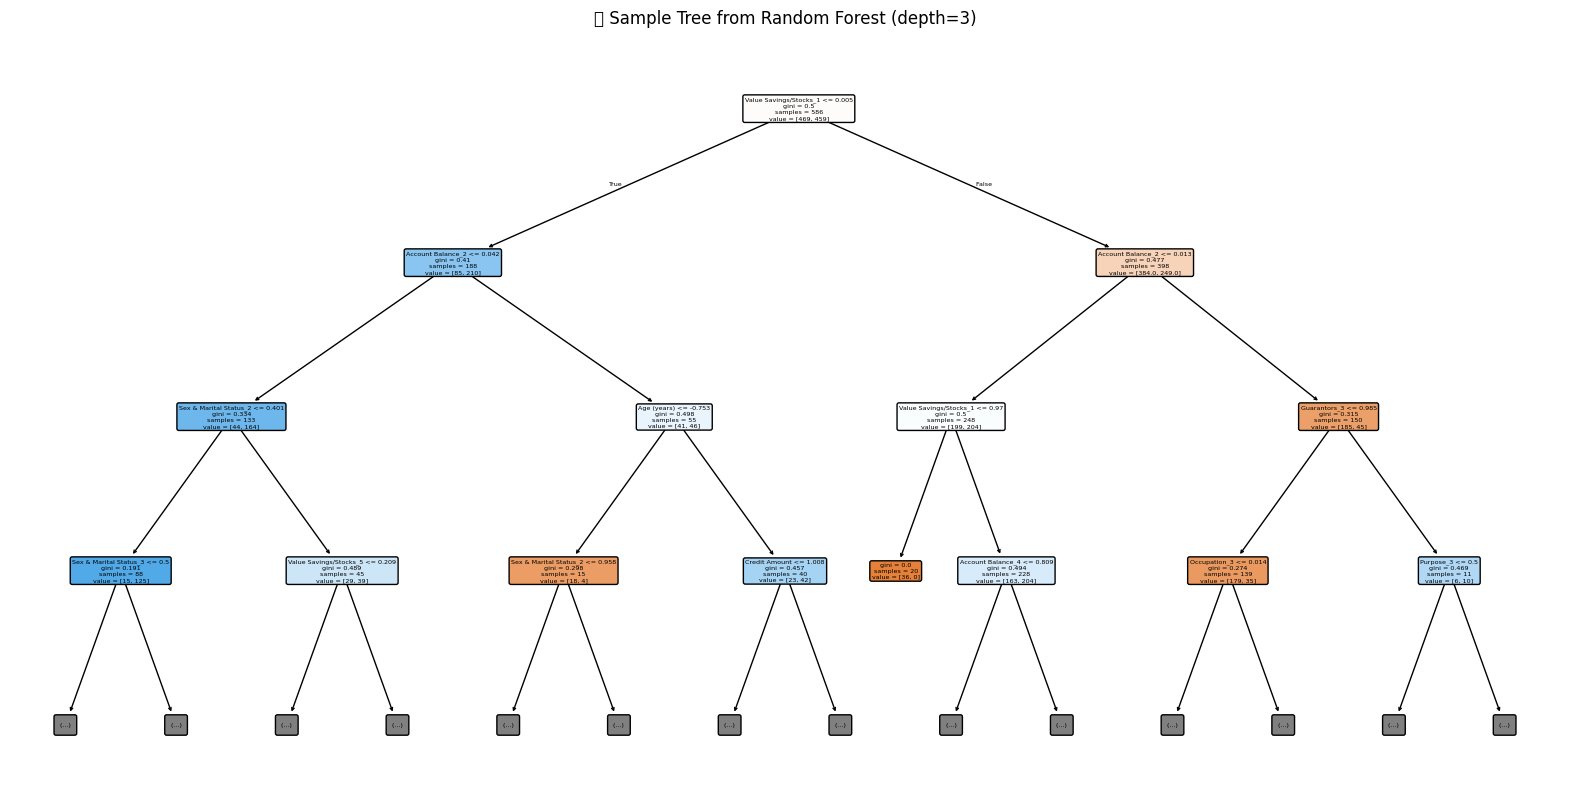


📊 Top 3 Naive Bayes Discriminative Features:
Duration of Credit (month): Δmean = 0.5768
Account Balance_4: Δmean = 0.3765
Credit Amount: Δmean = 0.3243

💸 Evaluating money impact for: KNN...

💸 Evaluating money impact for: DecisionTree...

💸 Evaluating money impact for: RandomForest...

💸 Evaluating money impact for: XGBoost...

💸 Evaluating money impact for: NaiveBayes...

💰 Money Impact Comparison:
       Model      FN Impact  FP Impact  TN Impact     TP Impact    Net Impact
         KNN -170809.859434   -91614.6   141873.0 251019.633164 130468.173730
DecisionTree -160307.477442   -89397.6   144090.0 261522.015156 155906.937714
RandomForest -102120.880287  -100901.4   132586.2 319708.612311 249272.532024
     XGBoost -113679.295518  -111520.8   121966.8 308150.197080 204916.901562
  NaiveBayes -226007.469587   -53470.2   180017.4 195822.023011  96361.753424


In [ ]:
best_model, all_models, money_impact_df = best_classifier(
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test,
    df,            # your original DataFrame
    LGD=0.6,       # default loss given default
    annual_rate=0.20  # now using 20% annual rate
)
